In [1]:
import os
import time
import random
import warnings

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from lxml import etree # type: ignore <- pylance milně hlásí chybu
from pathlib import Path
import time
import sys
import polars as pl
import polars.selectors as cs
import json
import pickle
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from ydata_profiling import ProfileReport

from utils import *
from schemas import *
from processing import *

pl.Config.set_tbl_cols(-1)
os.chdir(r'E:\CVUT_BAP')
SEED=42

# Načtení dat

### Data z měřících přístrojů

In [2]:
df_mereni = cast_mereni(pl.read_parquet('kod/data/data_z_mericich_pristroju/parquet/nafta_osobni', schema=nafta_schema)).sample(fraction=1.0, shuffle=True, seed=SEED)
describe(df_mereni)

(7584204, 143)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek,Benzin_PocetVyusteni,Plyn_PocetVyusteni,Obd_Readiness_J1939_Pritomno,Obd_Readiness_Zazeh_Pritomno
0,CZ-440114-23-07-0254,2023-07-11,440114,2023-07-11 08:48:36.197,2023-07-11 09:11:53.243,50975,CZ-440114-23-07-0254,2023-07-11 09:11:50.822152,Bosch,BEA 950,...,5001.0,1.0,849.0,1.0,82.0,2.0,0,0,False,False
1,CZ-530507-21-05-0096,2021-05-07,530507,2021-05-07 11:48:28.930,2021-05-07 11:55:08.443,18917,CZ-530507-21-05-0096,2021-05-07 11:51:00.000000,Bosch,RTM430,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False
2,CZ-421134-21-07-0671,2021-07-27,421134,2021-07-27 09:01:39.600,2021-07-27 09:14:32.120,42887,CZ-421134-21-07-0671,2021-07-27 00:00:00.000000,ActiaCZ,AT605,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False
3,CZ-540514-20-10-3339,2020-10-21,540514,2020-10-21 14:56:09.460,2020-10-21 15:05:56.360,34771,CZ-540514-20-10-3339,2020-10-21 14:59:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False
4,CZ-430834-19-05-0140,2019-05-13,430834,2019-05-13 08:17:12.950,2019-05-13 08:46:57.340,9855,CZ-430834-19-05-0140,2019-05-13 08:23:00.000000,Bosch,RTM430,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False
5,CZ-480933-23-11-0056,2023-11-03,480933,2023-11-03 09:19:03.677,2023-11-03 09:35:01.523,49817,CZ-480933-23-11-0056,2023-11-03 09:25:00.000000,ATAL s.r.o.,AT605,...,4230.0,1.0,810.0,1.0,70.0,1.0,0,0,False,False
6,CZ-410907-20-04-0332,2020-04-22,410907,2020-04-22 14:36:34.107,2020-04-22 14:48:05.310,42311,CZ-410907-20-04-0332,2020-04-22 14:36:34.000000,Bosch,RTM430,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False
7,CZ-571305-23-09-0019,2023-09-18,571305,2023-09-18 09:07:49.550,2023-09-18 09:13:31.767,44159,CZ-571305-23-09-0019,2023-09-18 09:13:26.463085,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False
8,CZ-480410-25-08-0083,2025-08-21,480410,2025-08-21 09:54:11.507,2025-08-21 10:05:43.093,106207,CZ-480410-25-08-0083,2025-08-21 10:04:00.000000,MAHLE,OPA-100,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False
9,CZ-480558-25-09-0381,2025-09-08,480558,2025-09-08 11:35:12.640,2025-09-08 11:47:17.650,89487,CZ-480558-25-09-0381,2025-09-08 11:38:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False


,0
CisloProtokolu,7584204 / 7584204
DatumProhlidky,7584204 / 7584204
StaniceCislo,7584204 / 7584204
Zahajeni,7551329 / 7584204
Ukonceni,7551329 / 7584204
...,...
Nafta_Mereni3_Teplota_Vysledek,2005809 / 7584204
Benzin_PocetVyusteni,7584204 / 7584204
Plyn_PocetVyusteni,7584204 / 7584204
Obd_Readiness_J1939_Pritomno,7584204 / 7584204


CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,MericiPristroj_Verze,MericiPristroj_OBD,MericiPristroj_VerzeSoftware,Poznamky,Vozidlo_Vin,Vozidlo_Znacka,Vozidlo_ObchodniOznaceni,Vozidlo_TypMotoru,Vozidlo_CisloMotoru,Vozidlo_Odometer,Vozidlo_RokVyroby,Vozidlo_DatumPrvniRegistrace,Vozidlo_Palivo,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotka,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Vysledek_TesnostPlynovehoZarizeni,Vysledek_Vyhovuje,PristiProhlidka,EmisniSystem,Obd_KomunikacniProtokol,Obd_Vin,Obd_PocetDtc,Obd_VzdalenostDtc,Obd_CasDtc,Obd_KontrolaMil,Obd_VypisDtc,Zavady,Obd_Readiness_Vysledek,Obd_Readiness_Vznet_AC_Podporovano,Obd_Readiness_Vznet_AC_Otestovano,Obd_Readiness_Vznet_BOOST_Podporovano,Obd_Readiness_Vznet_BOOST_Otestovano,Obd_Readiness_Vznet_COMP_Podporovano,Obd_Readiness_Vznet_COMP_Otestovano,Obd_Readiness_Vznet_DPF_Podporovano,Obd_Readiness_Vznet_DPF_Otestovano,Obd_Readiness_Vznet_EGR-VVT_Podporovano,Obd_Readiness_Vznet_EGR-VVT_Otestovano,Obd_Readiness_Vznet_EGS_Podporovano,Obd_Readiness_Vznet_EGS_Otestovano,Obd_Readiness_Vznet_FUEL_Podporovano,Obd_Readiness_Vznet_FUEL_Otestovano,Obd_Readiness_Vznet_MISF_Podporovano,Obd_Readiness_Vznet_MISF_Otestovano,Obd_Readiness_Vznet_NMHC_Podporovano,Obd_Readiness_Vznet_NMHC_Otestovano,Obd_Readiness_Vznet_NOX_Podporovano,Obd_Readiness_Vznet_NOX_Otestovano,Obd_Readiness_Vznet_RESERVE_Podporovano,Obd_Readiness_Vznet_RESERVE_Otestovano,Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota,Nafta_MereniVznetLimit_OtackyVolnobezne_Min_RucniZadani,Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota,Nafta_MereniVznetLimit_OtackyVolnobezne_Max_RucniZadani,Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota,Nafta_MereniVznetLimit_OtackyPrebehove_Min_RucniZadani,Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota,Nafta_MereniVznetLimit_OtackyPrebehove_Max_RucniZadani,Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota,Nafta_MereniVznetLimit_CasAkcelerace_Max_RucniZadani,Nafta_MereniVznetLimit_Kourivost_Max_Hodnota,Nafta_MereniVznetLimit_Kourivost_Max_RucniZadani,Nafta_MereniVznetLimit_KourivostRozpeti_Max_Hodnota,Nafta_MereniVznetLimit_KourivostRozpeti_Max_RucniZadani,Nafta_Palivo,Nafta_PocetVyusteni,Nafta_MereniPrumer_TPS_Hodnota,Nafta_MereniPrumer_TPS_Vysledek,Nafta_MereniPrumer_CasAkcelerace_Hodnota,Nafta_MereniPrumer_CasAkcelerace_Vysledek,Nafta_MereniPrumer_Kourivost_Hodnota,Nafta_MereniPrumer_Kourivost_Vysledek,Nafta_MereniPrumer_OtackyPrebehove_Hodnota,Nafta_MereniPrumer_OtackyPrebehove_Vysledek,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota,Nafta_MereniPrumer_OtackyVolnobezne_Vysledek,Nafta_MereniPrumer_Teplota_Hodnota,Nafta_MereniPrumer_Teplota_Vysledek,Nafta_Mereni0_TPS_Hodnota,Nafta_Mereni0_TPS_Vysledek,Nafta_Mereni0_CasAkcelerace_Hodnota,Nafta_Mereni0_CasAkcelerace_Vysledek,Nafta_Mereni0_Kourivost_Hodnota,Nafta_Mereni0_Kourivost_Vysledek,Nafta_Mereni0_OtackyPrebehove_Hodnota,Nafta_Mereni0_OtackyPrebehove_Vysledek,Nafta_Mereni0_OtackyVolnobezne_Hodnota,Nafta_Mereni0_OtackyVolnobezne_Vysledek,Nafta_Mereni0_Teplota_Hodnota,Nafta_Mereni0_Teplota_Vysledek,Nafta_Mereni1_TPS_Hodnota,Nafta_Mereni1_TPS_Vysledek,Nafta_Mereni1_CasAkcelerace_Hodnota,Nafta_Mereni1_CasAkcelerace_Vysledek,Nafta_Mereni1_Kourivost_Hodnota,Nafta_Mereni1_Kourivost_Vysledek,Nafta_Mereni1_OtackyPrebehove_Hodnota,Nafta_Mereni1_OtackyPrebehove_Vysledek,Nafta_Mereni1_OtackyVolnobezne_Hodnota,Nafta_Mereni1_OtackyVolnobezne_Vysledek,Nafta_Mereni1_Teplota_Hodnota,Nafta_Mereni1_Teplota_Vysledek,Nafta_Mereni2_TPS_Hodnota,Nafta_Mereni2_TPS_Vysledek,Nafta_Mereni2_CasAkcelerace_Hodnota,Nafta_Mereni2_CasAkcelerace_Vysledek,Nafta_Mereni2_Kourivost_Hodnota,Nafta_Mereni2_Kourivost_Vysledek,Nafta_Mereni2_OtackyPrebehove_Hodnota,Nafta_Mereni2_OtackyPrebehove_Vysledek,Nafta_Mereni2_OtackyVolnobezne_Hodnota,Nafta_Mereni2_OtackyVolnobezne_Vysledek,Nafta_Mereni2_Teplota_Hodnota,Nafta_Mereni2_Teplota_Vysled

### Prohlídky vozidel STK a SME

In [3]:
df_technicka = transform_prohlidka(cast_prohlidka(pl.read_parquet('kod/data/prohlidky_vozidel_stk_a_sme/parquet/prohlidky', schema=prohlidky_schema)))
describe(df_technicka)

(20060291, 35)


,CisloProtokolu,DatumProhlidky,DruhProhlidky,Prohlidka_OdpovednaOsoba,Prohlidka_Stanice_Cislo,Prohlidka_Stanice_Kraj,Prohlidka_Stanice_ORP,Prohlidka_Stanice_Obec,Prohlidka_Zahajeni,Prohlidka_Ukonceni,...,Emise_Ukonceni,Emise_OdpovednaOsoba,Emise_EmisniSystem,Emise_VyrobceMotoru,Emise_CisloMotoru,Vysledek_Odometr,Vysledek_Poznamka,Vysledek_DatumPristiProhlidky,Vysledek_Celkovy,Technicka_Pritomo
0,CZ-520406-19-01-0001,2019-01-01,Pravidelná,16835,520406,Středočeský kraj,Kolín,Žabonosy,2019-01-01 15:21:49.077,2019-01-01 15:40:05.470,...,2019-01-01 15:39:51.550,16835,Řízený s OBD,None,None,309068.0,None,2021-01-01,1,False
1,CZ-420930-19-01-0001,2019-01-01,Pravidelná,43281,420930,Středočeský kraj,Říčany,Říčany,2019-01-01 14:35:04.440,2019-01-01 15:06:17.843,...,2019-01-01 15:06:04.390,47287,Řízený bez OBD,None,None,169952.0,None,2021-01-01,1,False
2,CZ-480811-23-01-0001,2023-01-01,Pravidelná,36479,480811,Olomoucký kraj,Přerov,Kojetín,2023-01-01 12:21:49.857,2023-01-01 12:36:59.853,...,2023-01-01 12:36:18.700,36479,Řízený s OBD,None,None,241379.0,None,2025-01-01,1,False
3,CZ-420221-23-01-0004,2023-01-01,Pravidelná,44365,420221,Středočeský kraj,Beroun,Bavoryně,2023-01-01 17:25:41.657,2023-01-01 17:42:24.763,...,2023-01-01 17:41:10.160,44365,Řízený s OBD,None,-,65923.0,None,2025-01-01,1,False
4,CZ-420221-23-01-0001,2023-01-01,Pravidelná,44365,420221,Středočeský kraj,Beroun,Bavoryně,2023-01-01 16:05:05.460,2023-01-01 16:20:09.770,...,2023-01-01 16:17:16.030,44365,Řízený s OBD,None,-,264005.0,None,2025-01-01,1,False
5,CZ-420221-23-01-0003,2023-01-01,Pravidelná,44365,420221,Středočeský kraj,Beroun,Bavoryně,2023-01-01 16:56:47.653,2023-01-01 17:07:00.677,...,2023-01-01 17:06:11.830,44365,Řízený s OBD,None,-,146446.0,None,2025-01-01,1,False
6,CZ-170901-23-01-0001,2023-01-01,Pravidelná,89493,170901,Olomoucký kraj,Prostějov,Bedihošť,2023-01-01 19:23:52.253,2023-01-01 19:36:57.250,...,2023-01-01 19:36:25.527,89493,Řízený s OBD,None,None,237886.0,None,2025-01-01,1,False
7,CZ-170901-23-01-0002,2023-01-01,Pravidelná,89493,170901,Olomoucký kraj,Prostějov,Bedihošť,2023-01-01 19:40:36.197,2023-01-01 19:53:31.853,...,2023-01-01 19:53:03.310,89493,Řízený s OBD,None,None,210028.0,None,2025-01-01,1,False
8,CZ-520406-24-01-0001,2024-01-01,Pravidelná,1308,520406,Středočeský kraj,Kolín,Žabonosy,2024-01-01 11:30:09.453,2024-01-01 11:49:50.820,...,2024-01-01 11:48:07.520,1308,Řízený s OBD,None,None,237115.0,None,2026-01-01,1,False
9,CZ-480811-24-01-0001,2024-01-01,Pravidelná,36479,480811,Olomoucký kraj,Přerov,Kojetín,2024-01-01 16:21:48.953,2024-01-01 16:36:21.950,...,2024-01-01 16:36:09.930,36479,Řízený s OBD,None,None,263886.0,None,2026-01-01,1,False


,0
CisloProtokolu,20060291 / 20060291
DatumProhlidky,20060291 / 20060291
DruhProhlidky,20060291 / 20060291
Prohlidka_OdpovednaOsoba,20060291 / 20060291
Prohlidka_Stanice_Cislo,20060291 / 20060291
Prohlidka_Stanice_Kraj,20060291 / 20060291
Prohlidka_Stanice_ORP,20060291 / 20060291
Prohlidka_Stanice_Obec,20060291 / 20060291
Prohlidka_Zahajeni,20060291 / 20060291
Prohlidka_Ukonceni,20060291 / 20060291


CisloProtokolu,DatumProhlidky,DruhProhlidky,Prohlidka_OdpovednaOsoba,Prohlidka_Stanice_Cislo,Prohlidka_Stanice_Kraj,Prohlidka_Stanice_ORP,Prohlidka_Stanice_Obec,Prohlidka_Zahajeni,Prohlidka_Ukonceni,AdministrativniOprava_CisloProtokolu,AdministrativniOprava_DatumProhlidky,Vozidlo_Vin,Vozidlo_Kategorie,Vozidlo_Provedeni,Vozidlo_Znacka,Vozidlo_ObchodniOznaceni,Vozidlo_TypMotoru,Registrace_DatumPrvni,Registrace_Stat,Registrace_CisloDokladu,Emise_CisloProtokolu,Emise_DatumProhlidky,Emise_StaniceCislo,Emise_Zahajeni,Emise_Ukonceni,Emise_OdpovednaOsoba,Emise_EmisniSystem,Emise_VyrobceMotoru,Emise_CisloMotoru,Vysledek_Odometr,Vysledek_Poznamka,Vysledek_DatumPristiProhlidky,Vysledek_Celkovy,Technicka_Pritomo
str,date,str,i32,i32,str,str,str,datetime[μs],datetime[μs],str,date,str,str,str,str,str,str,str,str,str,str,datetime[μs],i32,datetime[μs],datetime[μs],i32,enum,str,str,i32,str,date,i8,bool
"""CZ-520406-19-01-0001""",2019-01-01,"""Pravidelná""",16835,520406,"""Středočeský kraj""","""Kolín""","""Žabonosy""",2019-01-01 15:21:49.077,2019-01-01 15:40:05.470,null,null,"""WV1ZZZ7HZ7H079425""","""N1""",null,"""VW""","""TRANSPORTER""","""BPC""","""2007-01-03T00:00:00.0000000+01…","""Česká republika""","""UB654181""","""CZ-520406-19-01-0001""",2019-01-01 15:40:05.470,520406,2019-01-01 15:22:33.290,2019-01-01 15:39:51.550,16835,"""Řízený s OBD""",null,null,309068,null,2021-01-01,1,false


### Stanice STK a SME

In [4]:
df_stanice = transform_stanice(cast_stanice(pl.read_parquet('kod/data/stanice_stk_a_sme/parquet/stanice', schema=stanice_schema)))
describe(df_stanice)

(1409, 16)


,Stanice_Cislo,Stanice_Adresa_Kraj,Stanice_Adresa_Okres,Stanice_Adresa_Orp,Stanice_Adresa_Obec,Provozovatel_Nazev,Provozovatel_Adresa_Obec,Provozovatel_Kontakt_Telefon,Provozovatel_Kontakt_Email,Stk_Pritomno,Adr_Pritomno,SmeZkusebni_Pritomno,Sme_Pritomno,Sme_Osvedceni_Kategorie,Sme_Osvedceni_EmisniSystem,Sme_Osvedceni_Palivo
0,110301,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Emitech s.r.o.,Praha,True,True,False,False,False,True,4.0,2.0,2.0
1,110302,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,E2F2 s.r.o.,Praha,True,True,False,False,False,True,2.0,2.0,4.0
2,110401,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Tomáš Krejčí,Praha,True,True,False,False,False,True,2.0,2.0,4.0
3,110501,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Daimler Truck Česká republika s.r.o.,Praha,True,True,False,False,False,True,9.0,2.0,3.0
4,110502,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Autosprint Stodůlky s.r.o.,Praha,False,True,False,False,False,True,7.0,2.0,3.0
5,110503,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,AUTOTEST-EMISE MOTOL s.r.o.,Praha,True,True,False,False,False,True,2.0,2.0,4.0
6,110601,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,AUTO PAPOUŠEK s.r.o.,Praha,True,True,False,False,False,True,2.0,2.0,2.0
7,110801,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,CZ MARTIN Oil s.r.o.,Praha,False,True,False,False,False,True,7.0,2.0,4.0
8,110802,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Jan Holub,Praha,True,True,False,False,False,True,7.0,2.0,4.0
9,110901,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,E2F2 s.r.o.,Praha,True,True,False,False,False,True,2.0,2.0,4.0


,0
Stanice_Cislo,1409 / 1409
Stanice_Adresa_Kraj,1409 / 1409
Stanice_Adresa_Okres,1409 / 1409
Stanice_Adresa_Orp,1409 / 1409
Stanice_Adresa_Obec,1409 / 1409
Provozovatel_Nazev,1409 / 1409
Provozovatel_Adresa_Obec,1409 / 1409
Provozovatel_Kontakt_Telefon,1409 / 1409
Provozovatel_Kontakt_Email,1409 / 1409
Stk_Pritomno,1409 / 1409


Stanice_Cislo,Stanice_Adresa_Kraj,Stanice_Adresa_Okres,Stanice_Adresa_Orp,Stanice_Adresa_Obec,Provozovatel_Nazev,Provozovatel_Adresa_Obec,Provozovatel_Kontakt_Telefon,Provozovatel_Kontakt_Email,Stk_Pritomno,Adr_Pritomno,SmeZkusebni_Pritomno,Sme_Pritomno,Sme_Osvedceni_Kategorie,Sme_Osvedceni_EmisniSystem,Sme_Osvedceni_Palivo
i32,str,str,str,str,str,str,bool,bool,bool,bool,bool,bool,list[str],list[str],list[str]
110301,"""Hlavní město Praha""","""Hlavní město Praha""","""Hlavní město Praha""","""Praha""","""Emitech s.r.o.""","""Praha""",true,true,false,false,false,true,"[""M1"", ""M2"", … ""N2""]","[""NERIZENY"", ""RIZENY""]","[""BA"", ""NM""]"


# Propojení datasetů
### Odstranění duplikátních čísel protokolu
Drtivá většina protokolů má unikátní čílo.  
Vzácně se celý řádek vyskytuje duplicitně uvedený.  
Pouze v jednotlivých případech se čísla protokolů shodují při neidentických ostatních polích - stejný protokol evidován na dvou různých stanicích.

In [5]:
df_mereni = remove_duplicate_cislo_protokolu(df_mereni)

Délka datasetu před odstraněním duplicitních řádků: 7584204
Délka datasetu po odstranění duplicitních řádků: 7583895
Neduplicitní řádky se shodným CisloProtokolu:
(2, 143)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek,Benzin_PocetVyusteni,Plyn_PocetVyusteni,Obd_Readiness_J1939_Pritomno,Obd_Readiness_Zazeh_Pritomno
0,CZ-540308-24-02-0512,2024-02-14,540308,2024-02-14 06:53:19.297,2024-02-14 07:09:35.900,102209,CZ-540308-24-02-0512,2024-02-14 07:08:34.888717,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False
1,CZ-540308-24-02-0512,2024-02-14,3420,2024-02-14 06:53:19.297,2024-02-14 07:09:35.900,69281,CZ-540308-24-02-0512,2024-02-14 07:08:34.888717,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False


Délka datasetu po odstranění duplicitních CisloProtokolu: 7583894


In [6]:
df_technicka = remove_duplicate_cislo_protokolu(df_technicka, 'Emise')

Délka datasetu před odstraněním duplicitních řádků: 20060291
Délka datasetu po odstranění duplicitních řádků: 20059452
Neduplicitní řádky se shodným Emise_CisloProtokolu:
(8, 35)


,CisloProtokolu,DatumProhlidky,DruhProhlidky,Prohlidka_OdpovednaOsoba,Prohlidka_Stanice_Cislo,Prohlidka_Stanice_Kraj,Prohlidka_Stanice_ORP,Prohlidka_Stanice_Obec,Prohlidka_Zahajeni,Prohlidka_Ukonceni,...,Emise_Ukonceni,Emise_OdpovednaOsoba,Emise_EmisniSystem,Emise_VyrobceMotoru,Emise_CisloMotoru,Vysledek_Odometr,Vysledek_Poznamka,Vysledek_DatumPristiProhlidky,Vysledek_Celkovy,Technicka_Pritomo
0,CZ-3420-24-02-0561,2024-02-15,Pravidelná,69,3420,Karlovarský kraj,Karlovy Vary,Karlovy Vary,2024-02-15 06:43:45.980,2024-02-15 11:12:22.117,...,2024-02-15 07:11:41.980,24305,Řízený bez OBD,None,None,214705,None,2026-02-15,1,True
1,CZ-3420-24-02-0512,2024-02-14,Pravidelná,69,3420,Karlovarský kraj,Karlovy Vary,Karlovy Vary,2024-02-14 06:51:17.590,2024-02-14 08:39:20.330,...,2024-02-14 07:09:35.900,69281,Řízený s OBD,None,None,183388,None,2026-02-14,1,True
2,CZ-550309-23-06-0452,2023-06-14,Pravidelná,2565,550309,Ústecký kraj,Chomutov,Spořice,2023-06-14 14:27:36.830,2023-06-14 15:54:35.763,...,2023-06-14 15:01:31.037,2565,Neřízený,None,None,263981,Vozidlo není opatřeno pomocným VIN.,2024-06-14,1,False
3,CZ-540308-24-02-0561,2024-02-15,Pravidelná,69,540308,Karlovarský kraj,Karlovy Vary,Karlovy Vary,2024-02-15 06:44:05.900,2024-02-15 11:12:22.117,...,2024-02-15 07:11:41.980,102209,Řízený bez OBD,None,None,214705,není pomocný vin,2026-02-15,1,False
4,CZ-540308-24-02-0512,2024-02-14,Pravidelná,69,540308,Karlovarský kraj,Karlovy Vary,Karlovy Vary,2024-02-14 06:52:36.710,2024-02-14 08:39:20.323,...,2024-02-14 07:09:35.900,102209,Řízený s OBD,None,None,183388,None,2026-02-14,1,False
5,CZ-3521-23-06-0452,2023-06-14,Pravidelná,2565,3521,Ústecký kraj,Chomutov,Spořice,2023-06-14 14:04:44.500,2023-06-14 15:54:35.757,...,2023-06-14 15:01:31.037,3329,Neřízený,None,None,263982,None,2024-06-14,1,True
6,CZ-3420-24-02-0563,2024-02-15,Pravidelná,69281,3420,Karlovarský kraj,Karlovy Vary,Karlovy Vary,2024-02-15 07:24:41.607,2024-02-15 11:54:41.417,...,2024-02-15 07:47:24.537,24305,Řízený s OBD,None,None,203129,None,2026-02-15,1,True
7,CZ-540308-24-02-0563,2024-02-15,Pravidelná,69281,540308,Karlovarský kraj,Karlovy Vary,Karlovy Vary,2024-02-15 07:24:55.643,2024-02-15 11:54:41.410,...,2024-02-15 07:47:24.537,102209,Řízený s OBD,None,None,203129,None,2026-02-15,1,False


Délka datasetu po odstranění duplicitních Emise_CisloProtokolu: 20059448


### Ostranění duplicitních čísel stanic
Žádná stanice však v současnosti není v souboru duplicitně uvedená

In [7]:
short_display(df_stanice.filter(pl.col('Stanice_Cislo').count().over('Stanice_Cislo') > 1))
df_stanice = df_stanice.unique()

(0, 16)


,Stanice_Cislo,Stanice_Adresa_Kraj,Stanice_Adresa_Okres,Stanice_Adresa_Orp,Stanice_Adresa_Obec,Provozovatel_Nazev,Provozovatel_Adresa_Obec,Provozovatel_Kontakt_Telefon,Provozovatel_Kontakt_Email,Stk_Pritomno,Adr_Pritomno,SmeZkusebni_Pritomno,Sme_Pritomno,Sme_Osvedceni_Kategorie,Sme_Osvedceni_EmisniSystem,Sme_Osvedceni_Palivo


## Samotný join

In [ ]:
df = (df_mereni
      .join(df_technicka, left_on='CisloProtokolu', right_on='Emise_CisloProtokolu', how='left', suffix='_P')
      .join(df_stanice.with_columns(pl.col('Stanice_Cislo')), left_on='StaniceCislo', right_on='Stanice_Cislo', how='left', suffix='_S')
)
del df_mereni, df_technicka, df_stanice
describe(df)

(7583894, 192)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Provozovatel_Adresa_Obec,Provozovatel_Kontakt_Telefon,Provozovatel_Kontakt_Email,Stk_Pritomno,Adr_Pritomno,SmeZkusebni_Pritomno,Sme_Pritomno,Sme_Osvedceni_Kategorie,Sme_Osvedceni_EmisniSystem,Sme_Osvedceni_Palivo
0,CZ-420932-21-02-0031,2021-02-01,420932,2021-02-01 17:30:15.480,2021-02-01 17:39:37.420,49767,CZ-420932-21-02-0031,2021-02-01 17:34:00.000000,Bosch,BEA070,...,Brandýs nad Labem-Stará Bolesl,True,True,False,False,False,True,NaN,2,4
1,CZ-460238-23-01-0094,2023-01-11,460238,2023-01-11 09:19:20.890,2023-01-11 09:25:58.910,16913,CZ-460238-23-01-0094,2023-01-11 09:25:00.000000,ACTIA CZ s.r.o.,AT605,...,Měník,True,True,False,False,False,True,NaN,2,2
2,CZ-480512-19-08-0491,2019-08-21,480512,2019-08-21 12:42:47.443,2019-08-21 12:53:18.383,36395,CZ-480512-19-08-0491,2019-08-21 12:51:00.000000,ActiaCZ,AT605,...,Nové Strašecí,True,True,False,False,False,True,NaN,2,4
3,CZ-470632-21-10-0037,2021-10-07,470632,2021-10-07 13:57:02.033,2021-10-07 14:17:33.653,43185,CZ-470632-21-10-0037,2021-10-07 14:11:00.000000,BRAIN BEE,OPA-100,...,Mikulčice,False,True,False,False,False,True,NaN,2,2
4,CZ-170902-24-09-0394,2024-09-30,170902,2024-09-30 11:16:17.327,2024-09-30 11:25:57.967,97473,CZ-170902-24-09-0394,2024-09-30 11:23:00.000000,MAHLE,OPA-100,...,Prostějov,True,True,False,False,False,True,2.0,2,4
5,CZ-460223-22-10-0747,2022-10-31,460223,2022-10-31 08:22:22.120,2022-10-31 08:29:57.960,44595,CZ-460223-22-10-0747,2022-10-31 08:29:57.064065,Bosch,BEA 950,...,Sovětice,True,True,False,False,False,True,5.0,2,3
6,CZ-410945-22-02-0233,2022-02-07,410945,2022-02-07 17:38:52.670,2022-02-07 17:46:38.783,2171,CZ-410945-22-02-0233,2022-02-07 17:46:25.762810,Bosch,BEA 950,...,Praha,True,True,False,False,False,True,NaN,2,4
7,CZ-560306-21-05-0158,2021-05-25,560306,2021-05-25 11:14:48.513,2021-05-25 11:21:35.700,41459,CZ-560306-21-05-0158,2021-05-25 11:19:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,Chrudim,False,True,False,False,False,True,NaN,2,4
8,CZ-540906-22-09-0229,2022-09-15,540906,2022-09-15 10:22:36.890,2022-09-15 10:37:05.710,54525,CZ-540906-22-09-0229,2022-09-15 10:28:55.345911,Bosch,BEA 950,...,Chodov,True,True,False,False,False,True,NaN,2,4
9,CZ-520406-23-10-0047,2023-10-15,520406,2023-10-15 09:20:02.417,2023-10-15 09:35:39.070,16835,CZ-520406-23-10-0047,2023-10-15 09:28:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,Žabonosy,True,True,False,False,False,True,NaN,2,2


,0
CisloProtokolu,7583894 / 7583894
DatumProhlidky,7583894 / 7583894
StaniceCislo,7583894 / 7583894
Zahajeni,7551021 / 7583894
Ukonceni,7551021 / 7583894
...,...
SmeZkusebni_Pritomno,7385798 / 7583894
Sme_Pritomno,7385798 / 7583894
Sme_Osvedceni_Kategorie,3561927 / 7583894
Sme_Osvedceni_EmisniSystem,7377480 / 7583894


CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,MericiPristroj_Verze,MericiPristroj_OBD,MericiPristroj_VerzeSoftware,Poznamky,Vozidlo_Vin,Vozidlo_Znacka,Vozidlo_ObchodniOznaceni,Vozidlo_TypMotoru,Vozidlo_CisloMotoru,Vozidlo_Odometer,Vozidlo_RokVyroby,Vozidlo_DatumPrvniRegistrace,Vozidlo_Palivo,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotka,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Vysledek_TesnostPlynovehoZarizeni,Vysledek_Vyhovuje,PristiProhlidka,EmisniSystem,Obd_KomunikacniProtokol,Obd_Vin,Obd_PocetDtc,Obd_VzdalenostDtc,Obd_CasDtc,Obd_KontrolaMil,Obd_VypisDtc,Zavady,Obd_Readiness_Vysledek,Obd_Readiness_Vznet_AC_Podporovano,Obd_Readiness_Vznet_AC_Otestovano,Obd_Readiness_Vznet_BOOST_Podporovano,Obd_Readiness_Vznet_BOOST_Otestovano,Obd_Readiness_Vznet_COMP_Podporovano,Obd_Readiness_Vznet_COMP_Otestovano,Obd_Readiness_Vznet_DPF_Podporovano,Obd_Readiness_Vznet_DPF_Otestovano,Obd_Readiness_Vznet_EGR-VVT_Podporovano,Obd_Readiness_Vznet_EGR-VVT_Otestovano,Obd_Readiness_Vznet_EGS_Podporovano,Obd_Readiness_Vznet_EGS_Otestovano,Obd_Readiness_Vznet_FUEL_Podporovano,Obd_Readiness_Vznet_FUEL_Otestovano,Obd_Readiness_Vznet_MISF_Podporovano,Obd_Readiness_Vznet_MISF_Otestovano,Obd_Readiness_Vznet_NMHC_Podporovano,Obd_Readiness_Vznet_NMHC_Otestovano,Obd_Readiness_Vznet_NOX_Podporovano,Obd_Readiness_Vznet_NOX_Otestovano,Obd_Readiness_Vznet_RESERVE_Podporovano,Obd_Readiness_Vznet_RESERVE_Otestovano,Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota,Nafta_MereniVznetLimit_OtackyVolnobezne_Min_RucniZadani,Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota,Nafta_MereniVznetLimit_OtackyVolnobezne_Max_RucniZadani,Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota,Nafta_MereniVznetLimit_OtackyPrebehove_Min_RucniZadani,Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota,Nafta_MereniVznetLimit_OtackyPrebehove_Max_RucniZadani,Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota,Nafta_MereniVznetLimit_CasAkcelerace_Max_RucniZadani,Nafta_MereniVznetLimit_Kourivost_Max_Hodnota,Nafta_MereniVznetLimit_Kourivost_Max_RucniZadani,Nafta_MereniVznetLimit_KourivostRozpeti_Max_Hodnota,Nafta_MereniVznetLimit_KourivostRozpeti_Max_RucniZadani,Nafta_Palivo,Nafta_PocetVyusteni,Nafta_MereniPrumer_TPS_Hodnota,Nafta_MereniPrumer_TPS_Vysledek,Nafta_MereniPrumer_CasAkcelerace_Hodnota,Nafta_MereniPrumer_CasAkcelerace_Vysledek,Nafta_MereniPrumer_Kourivost_Hodnota,Nafta_MereniPrumer_Kourivost_Vysledek,Nafta_MereniPrumer_OtackyPrebehove_Hodnota,Nafta_MereniPrumer_OtackyPrebehove_Vysledek,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota,Nafta_MereniPrumer_OtackyVolnobezne_Vysledek,Nafta_MereniPrumer_Teplota_Hodnota,Nafta_MereniPrumer_Teplota_Vysledek,Nafta_Mereni0_TPS_Hodnota,Nafta_Mereni0_TPS_Vysledek,Nafta_Mereni0_CasAkcelerace_Hodnota,Nafta_Mereni0_CasAkcelerace_Vysledek,Nafta_Mereni0_Kourivost_Hodnota,Nafta_Mereni0_Kourivost_Vysledek,Nafta_Mereni0_OtackyPrebehove_Hodnota,Nafta_Mereni0_OtackyPrebehove_Vysledek,Nafta_Mereni0_OtackyVolnobezne_Hodnota,Nafta_Mereni0_OtackyVolnobezne_Vysledek,Nafta_Mereni0_Teplota_Hodnota,Nafta_Mereni0_Teplota_Vysledek,Nafta_Mereni1_TPS_Hodnota,Nafta_Mereni1_TPS_Vysledek,Nafta_Mereni1_CasAkcelerace_Hodnota,Nafta_Mereni1_CasAkcelerace_Vysledek,Nafta_Mereni1_Kourivost_Hodnota,Nafta_Mereni1_Kourivost_Vysledek,Nafta_Mereni1_OtackyPrebehove_Hodnota,Nafta_Mereni1_OtackyPrebehove_Vysledek,Nafta_Mereni1_OtackyVolnobezne_Hodnota,Nafta_Mereni1_OtackyVolnobezne_Vysledek,Nafta_Mereni1_Teplota_Hodnota,Nafta_Mereni1_Teplota_Vysledek,Nafta_Mereni2_TPS_Hodnota,Nafta_Mereni2_TPS_Vysledek,Nafta_Mereni2_CasAkcelerace_Hodnota,Nafta_Mereni2_CasAkcelerace_Vysledek,Nafta_Mereni2_Kourivost_Hodnota,Nafta_Mereni2_Kourivost_Vysledek,Nafta_Mereni2_OtackyPrebehove_Hodnota,Nafta_Mereni2_OtackyPrebehove_Vysledek,Nafta_Mereni2_OtackyVolnobezne_Hodnota,Nafta_Mereni2_OtackyVolnobezne_Vysledek,Nafta_Mereni2_Teplota_Hodnota,Nafta_Mereni2_Teplota_Vysled

### Podklady pro kontrolu konzistence dat

In [25]:
schema_description(df)

,column,sample,majority,non_null,dtype
0,CisloProtokolu,CZ-420932-21-02-0031,1 / 7 583 894,7 583 894 / 7 583 894,String
1,DatumProhlidky,2021-02-01,6 758 / 7 583 894,7 583 894 / 7 583 894,Date
2,StaniceCislo,420932,126 609 / 7 583 894,7 583 894 / 7 583 894,Int32
3,Zahajeni,2021-02-01 17:30:15.480000,4 / 7 583 894,7 551 021 / 7 583 894,"Datetime(time_unit='us', time_zone=None)"
4,Ukonceni,2021-02-01 17:39:37.420000,3 / 7 583 894,7 551 021 / 7 583 894,"Datetime(time_unit='us', time_zone=None)"
...,...,...,...,...,...
187,SmeZkusebni_Pritomno,False,7 053 329 / 7 583 894,7 385 798 / 7 583 894,Boolean
188,Sme_Pritomno,True,7 385 798 / 7 583 894,7 385 798 / 7 583 894,Boolean
189,Sme_Osvedceni_Kategorie,"[M1, N1]",1 068 526 / 7 583 894,3 561 927 / 7 583 894,List(String)
190,Sme_Osvedceni_EmisniSystem,"[NERIZENY, RIZENY]",7 373 792 / 7 583 894,7 377 480 / 7 583 894,List(String)


# Kontrola konzistence dat
## CisloProtokolu

Neshoda mezi číslem protokolu a číslem protokolu prohlídky nastává zřídka. Nesoulad je způsoben vystavením samostatného protokolu namísto přiložení emistní kontroly pouze jako přílohy k technické kontrole. Pouze minimum protokolů bylo vystaveno na jiné stanici.

In [12]:
different_protocols = df.filter(pl.col('CisloProtokolu') != pl.col('Prohlidka_CisloProtokolu'))
short_display(different_protocols)
print(f'Podíl případů s odlišným číslem protokolu technické prohlídky a měření emisí {different_protocols.height / df.height * 100:.2f} %')
short_display(different_protocols.filter(pl.col('CisloProtokolu').str.split('-').list.get(1) != pl.col('Prohlidka_CisloProtokolu').str.split('-').list.get(1)))

(32086, 192)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Provozovatel_Adresa_Obec,Provozovatel_Kontakt_Telefon,Provozovatel_Kontakt_Email,Stk_Pritomno,Adr_Pritomno,SmeZkusebni_Pritomno,Sme_Pritomno,Sme_Osvedceni_Kategorie,Sme_Osvedceni_EmisniSystem,Sme_Osvedceni_Palivo
0,CZ-472203-19-07-0436,2019-07-12,472203,NaT,NaT,42967,CZ-472203-19-07-0431,2019-07-12 13:11:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,Brno,True,True,False,False,False,True,2.0,2.0,4.0
1,CZ-410445-20-01-0395,2020-01-16,410445,NaT,NaT,37527,CZ-410445-20-01-0394,2020-01-16 08:09:00.000000,ActiaCZ,AT605,...,Praha,True,True,False,False,False,True,NaN,2.0,4.0
2,CZ-441005-22-03-0016,2022-03-04,441005,NaT,NaT,36819,CZ-441005-22-03-0011,2022-03-03 10:16:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,None,None,None,None,None,None,None,NaN,NaN,NaN
3,CZ-510921-26-01-0206,2026-01-15,510921,NaT,NaT,104127,CZ-510921-26-01-0205,2026-01-15 12:47:00.000000,MAHLE,OPA-100,...,Praha,True,True,False,False,False,True,5.0,2.0,4.0
4,CZ-460214-19-01-0489,2019-01-11,460214,NaT,NaT,37931,CZ-460214-19-01-0488,2019-01-11 17:04:00.000000,Bosch,RTM430,...,Hradec Králové,True,True,False,False,False,True,NaN,2.0,4.0
5,CZ-480422-23-12-0233,2023-12-13,480422,NaT,NaT,85849,CZ-480422-23-12-0232,2023-12-13 07:22:00.000000,ATAL s.r.o.,AT605,...,Frenštát pod Radhoštěm,True,True,False,False,False,True,NaN,2.0,3.0
6,CZ-481022-20-11-0881,2020-11-25,481022,NaT,NaT,37429,CZ-481022-20-11-0880,2020-11-25 13:35:00.000000,ActiaCZ,AT605,...,Praha,True,True,False,False,False,True,NaN,2.0,3.0
7,CZ-441011-19-06-0230,2019-06-17,441011,NaT,NaT,32283,CZ-441011-19-06-0229,2019-06-17 11:19:00.000000,ActiaCZ,AT605,...,Plzeň,True,True,False,False,False,True,9.0,2.0,5.0
8,CZ-480117-19-04-0007,2019-04-01,480117,NaT,NaT,56115,CZ-480117-19-04-0002,2019-04-01 06:29:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,Roudno,True,True,False,False,False,True,4.0,2.0,5.0
9,CZ-111002-24-09-0333,2024-09-12,111002,NaT,NaT,95619,CZ-111002-24-09-0329,2024-09-12 14:44:00.000000,ATAL s.r.o.,AT605,...,Divišov,False,True,False,False,False,True,2.0,2.0,4.0


Podíl případů s odlišným číslem protokolu technické prohlídky a měření emisí 0.42 %
(104, 192)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Provozovatel_Adresa_Obec,Provozovatel_Kontakt_Telefon,Provozovatel_Kontakt_Email,Stk_Pritomno,Adr_Pritomno,SmeZkusebni_Pritomno,Sme_Pritomno,Sme_Osvedceni_Kategorie,Sme_Osvedceni_EmisniSystem,Sme_Osvedceni_Palivo
0,CZ-421024-21-09-0085,2021-09-02,421024,NaT,NaT,55185,CZ-410907-19-09-0026,2019-09-02 16:02:07.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,Praha 6 - Suchdol,True,True,False,False,False,True,NaN,2.0,4.0
1,CZ-570601-19-11-0021,2019-11-12,570601,NaT,NaT,37181,CZ-470634-19-11-0002,2019-11-01 06:51:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,Kyjov,False,True,False,False,False,True,NaN,2.0,1.0
2,CZ-420934-22-08-0108,2022-08-04,420934,NaT,NaT,34285,CZ-410445-18-08-0154,2018-08-07 11:31:00.000000,ActiaCZ,AT605,...,Praha,True,True,False,False,False,True,9.0,2.0,4.0
3,CZ-470543-19-09-0372,2019-09-27,470543,NaT,NaT,49391,CZ-470533-19-09-0207,2019-09-27 08:26:00.000000,Bosch,RTM430,...,Praha,True,True,False,False,False,True,8.0,2.0,4.0
4,CZ-420329-19-11-0484,2019-11-20,420329,NaT,NaT,40337,CZ-450710-17-12-0014,2017-12-01 10:08:00.000000,ActiaCZ,AT605,...,Kladno,True,True,False,False,False,True,2.0,2.0,2.0
5,CZ-420620-19-10-0657,2019-10-17,420620,NaT,NaT,15815,CZ-420619-19-10-0178,2019-10-17 09:55:00.000000,Bosch,RTM430,...,Mělník,False,True,False,False,False,True,6.0,2.0,5.0
6,CZ-440204-20-04-0042,2020-04-08,440204,NaT,NaT,36503,CZ-440213-18-04-0155,2018-04-09 14:10:00.000000,BOSCH,BEA-PC,...,Cheb,True,True,False,False,False,True,NaN,2.0,3.0
7,CZ-470543-21-03-0114,2021-03-05,470543,NaT,NaT,36421,CZ-470533-21-03-0074,2021-03-05 07:36:00.000000,Bosch,RTM430,...,Praha,True,True,False,False,False,True,8.0,2.0,4.0
8,CZ-570519-21-11-0028,2021-11-10,570519,NaT,NaT,37237,CZ-570505-19-11-0073,2019-11-12 08:18:05.000000,BOSCH,BEA-PC,...,Želechovice nad Dřevnicí,False,True,False,False,False,True,NaN,2.0,4.0
9,CZ-440704-21-11-0030,2021-11-01,440704,NaT,NaT,34767,CZ-540514-19-11-3559,2019-11-25 10:40:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,None,None,None,None,None,None,None,NaN,NaN,NaN


U některých vozidel je číslo měsíce zvýšeno o 50, nebo 70, což v metodice není explicitně řečeno.

In [15]:
date_mismatch = df.filter(pl.col('CisloProtokolu').str.split('-').list.slice(2, 2).list.join('-') != pl.col('DatumProhlidky').dt.strftime('%y-%m'))
short_display(date_mismatch)
date_mismatch_non_fifty = date_mismatch.filter(pl.col('CisloProtokolu').str.split('-').list.get(3).cast(pl.Int32) - 50 != pl.col('DatumProhlidky').dt.month()) 
short_display(date_mismatch_non_fifty)
short_display(date_mismatch_non_fifty.filter(pl.col('CisloProtokolu').str.split('-').list.get(3).cast(pl.Int32) - 70 != pl.col('DatumProhlidky').dt.month()))

(701, 192)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Provozovatel_Adresa_Obec,Provozovatel_Kontakt_Telefon,Provozovatel_Kontakt_Email,Stk_Pritomno,Adr_Pritomno,SmeZkusebni_Pritomno,Sme_Pritomno,Sme_Osvedceni_Kategorie,Sme_Osvedceni_EmisniSystem,Sme_Osvedceni_Palivo
0,CZ-421031-21-62-0011,2021-12-16,421031,NaT,NaT,89497,CZ-421031-21-62-0011,2021-12-16 09:18:00.000000,Bosch,BEA070,...,Březová-Oleško,True,True,False,False,False,True,NaN,2,2
1,CZ-460257-20-62-0016,2020-12-02,460257,NaT,NaT,43903,CZ-460257-20-62-0016,2020-12-02 13:29:00.000000,ActiaCZ,AT605,...,Třebechovice pod Orebem,True,False,False,False,False,True,NaN,2,3
2,CZ-460257-20-62-0001,2020-12-02,460257,NaT,NaT,43903,CZ-460257-20-62-0001,2020-12-02 08:57:00.000000,ActiaCZ,AT605,...,Třebechovice pod Orebem,True,False,False,False,False,True,NaN,2,3
3,CZ-460223-23-60-0001,2023-10-04,460223,NaT,NaT,94141,CZ-460223-23-60-0001,2023-10-04 07:27:00.000000,Bosch,BEA 950,...,Sovětice,True,True,False,False,False,True,5.0,2,3
4,CZ-540514-19-56-0007,2019-06-03,540514,NaT,NaT,6807,CZ-540514-19-56-0007,2019-06-03 11:18:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,Plzeň,True,True,False,False,False,True,9.0,2,4
5,CZ-450720-22-61-0005,2022-11-28,450720,NaT,NaT,66853,CZ-450720-22-61-0005,2022-11-28 12:17:00.000000,ACTIA CZ s.r.o.,AT605,...,Plzeň,True,True,False,False,False,True,NaN,2,4
6,CZ-471102-22-60-0003,2022-10-24,471102,NaT,NaT,2815,CZ-471102-22-60-0003,2022-10-24 09:28:00.000000,ACTIA CZ s.r.o.,AT605,...,Praha,True,True,False,False,False,True,NaN,2,5
7,CZ-430422-22-52-0002,2022-02-14,430422,NaT,NaT,29447,CZ-430422-22-52-0002,2022-02-14 11:51:00.000000,BRISK,JT 480a,...,Humpolec,True,True,False,False,False,True,7.0,2,4
8,CZ-410945-19-57-0015,2019-07-01,410945,NaT,NaT,55193,CZ-410945-19-57-0015,2019-07-01 11:46:00.000000,Bosch,RTM430,...,Praha,True,True,False,False,False,True,NaN,2,4
9,CZ-451034-19-54-0037,2019-04-02,451034,NaT,NaT,31961,CZ-451034-19-54-0037,2019-04-02 12:28:00.000000,Bosch,BEA070,...,Slaný,True,True,False,False,False,True,9.0,2,2


(16, 192)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Provozovatel_Adresa_Obec,Provozovatel_Kontakt_Telefon,Provozovatel_Kontakt_Email,Stk_Pritomno,Adr_Pritomno,SmeZkusebni_Pritomno,Sme_Pritomno,Sme_Osvedceni_Kategorie,Sme_Osvedceni_EmisniSystem,Sme_Osvedceni_Palivo
0,CZ-470909-23-71-0001,2023-01-03,470909,2023-01-03 14:16:12.247,2023-01-03 14:27:39.270,41941,CZ-470909-23-71-0001,2023-01-03 14:28:35.187414,Bosch,BEA 950,...,Prostějov,True,True,False,False,False,True,NaN,2,4
1,CZ-470324-24-71-0009,2024-01-17,470324,2024-01-17 12:16:03.327,2024-01-17 12:25:04.170,40999,CZ-470324-24-71-0009,2024-01-17 12:25:02.840465,Bosch,BEA 950,...,Modřice,True,True,False,False,False,True,4.0,2,5
2,CZ-470324-24-71-0005,2024-01-17,470324,2024-01-17 11:30:43.167,2024-01-17 11:41:29.533,41315,CZ-470324-24-71-0005,2024-01-17 11:39:51.212059,Bosch,BEA 950,...,Modřice,True,True,False,False,False,True,4.0,2,5
3,CZ-3832-22-77-0004,2022-07-04,3832,2022-07-04 12:33:42.040,2022-07-04 12:53:25.437,571,CZ-3832-22-77-0004,2022-07-04 12:53:00.000000,ActiaCZ,AT605,...,Karviná,True,True,True,False,True,True,NaN,2,5
4,CZ-470324-24-71-0011,2024-01-17,470324,2024-01-17 12:46:07.363,2024-01-17 13:02:37.090,41315,CZ-470324-24-71-0011,2024-01-17 13:00:56.177017,Bosch,BEA 950,...,Modřice,True,True,False,False,False,True,4.0,2,5
5,CZ-470324-24-71-0010,2024-01-17,470324,2024-01-17 12:38:24.703,2024-01-17 12:45:16.403,40999,CZ-470324-24-71-0010,2024-01-17 12:45:14.105427,Bosch,BEA 950,...,Modřice,True,True,False,False,False,True,4.0,2,5
6,CZ-3832-22-77-0003,2022-07-04,3832,2022-07-04 12:18:26.697,2022-07-04 12:26:51.067,47179,CZ-3832-22-77-0003,2022-07-04 12:26:00.000000,ActiaCZ,AT605,...,Karviná,True,True,True,False,True,True,NaN,2,5
7,CZ-470324-24-71-0013,2024-01-17,470324,2024-01-17 13:15:35.133,2024-01-17 13:25:03.427,41315,CZ-470324-24-71-0013,2024-01-17 13:23:42.062788,Bosch,BEA 950,...,Modřice,True,True,False,False,False,True,4.0,2,5
8,CZ-471413-24-71-0003,2024-01-17,471413,2024-01-17 14:31:50.350,2024-01-17 14:37:59.273,37841,None,NaT,None,None,...,Nové Veselí,False,True,False,False,False,True,5.0,2,5
9,CZ-471413-24-71-0002,2024-01-17,471413,2024-01-17 13:05:59.803,2024-01-17 13:13:00.317,37841,CZ-471413-24-71-0002,2024-01-17 13:12:59.019808,Bosch,BEA 950,...,Nové Veselí,False,True,False,False,False,True,5.0,2,5


(0, 192)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Provozovatel_Adresa_Obec,Provozovatel_Kontakt_Telefon,Provozovatel_Kontakt_Email,Stk_Pritomno,Adr_Pritomno,SmeZkusebni_Pritomno,Sme_Pritomno,Sme_Osvedceni_Kategorie,Sme_Osvedceni_EmisniSystem,Sme_Osvedceni_Palivo


## DatumProhlidky, Zahajeni, Ukonceni
Všechny prohlídky měly čas trvání věžší než 0.

In [16]:
short_display(df.filter(pl.col('Ukonceni') - pl.col('Zahajeni') <= 0))

(0, 192)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Provozovatel_Adresa_Obec,Provozovatel_Kontakt_Telefon,Provozovatel_Kontakt_Email,Stk_Pritomno,Adr_Pritomno,SmeZkusebni_Pritomno,Sme_Pritomno,Sme_Osvedceni_Kategorie,Sme_Osvedceni_EmisniSystem,Sme_Osvedceni_Palivo


Některé prohlídky mají velice krátký čas trvání. Pravděpodobně technik nespustil prohlídku na začátku a po skončení ji tepre oficiálně započal, aby zadal výsledky.

In [17]:
duration = (
    df
    .filter(pl.col('Zahajeni').is_not_null() & pl.col('Ukonceni').is_not_null())
    .select((pl.col('Ukonceni') - pl.col('Zahajeni')).alias('DelkaProhlidky'))
    .sort(by='DelkaProhlidky', descending=False)
)
display(duration)

DelkaProhlidky
duration[μs]
8s 24ms
8s 133ms
9s 840ms
9s 873ms
10s 67ms
…
8h 2m 41s 860ms
8h 5m 73ms
8h 9m 10s 543ms


Všechny prohlídky byly zahájeny a ukončeny v den datumu prohlídky -> **Odstranění "DatumProhlidky"**

In [ ]:
display(df.filter((pl.col('DatumProhlidky') != pl.col('Zahajeni').dt.date()) | (pl.col('DatumProhlidky') != pl.col('Ukonceni').dt.date())))
df = df.drop('DatumProhlidky')

# Explorační analýza dat

Rozdělení začátku a konce prohlídky během dne.

Rozdělení prohlídek v rámci měsíců.

Vývoj počtu prohlídek v letech.

Délka trvání prohlídky má lognormální rozdělení.

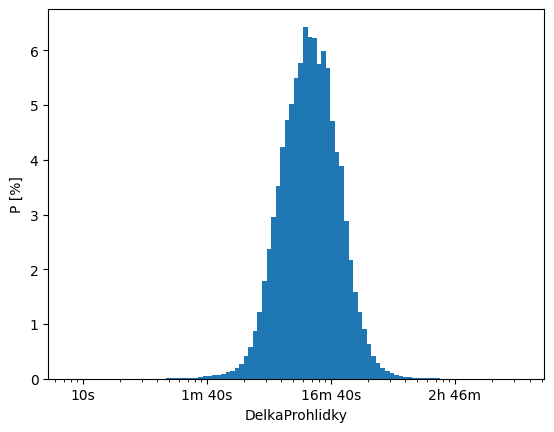

In [9]:
duration_s = (
    duration.select(pl.col('DelkaProhlidky').dt.total_seconds())
    .filter(pl.col('DelkaProhlidky') > 0)
    ['DelkaProhlidky'].to_pandas()
)
n_bins = 100
bins = np.logspace(np.log10(duration_s.min()), np.log10(duration_s.max()), n_bins)
weights = np.ones_like(duration_s) / len(duration_s) * n_bins
fig, ax = plt.subplots()
ax.hist(duration_s, bins=bins, weights=weights)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(FuncFormatter(sec_to_hms))
ax.set_xlabel('DelkaProhlidky')
ax.set_ylabel('P [%]')
plt.show()

## OdpovednaOsoba

In [27]:
short_display(df.filter(pl.col('OdpovednaOsoba') != pl.col('Prohlidka_OdpovednaOsoba')))

(1580888, 192)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Provozovatel_Adresa_Obec,Provozovatel_Kontakt_Telefon,Provozovatel_Kontakt_Email,Stk_Pritomno,Adr_Pritomno,SmeZkusebni_Pritomno,Sme_Pritomno,Sme_Osvedceni_Kategorie,Sme_Osvedceni_EmisniSystem,Sme_Osvedceni_Palivo
0,CZ-170902-24-09-0394,2024-09-30,170902,2024-09-30 11:16:17.327,2024-09-30 11:25:57.967,97473,CZ-170902-24-09-0394,2024-09-30 11:23:00.000000,MAHLE,OPA-100,...,Prostějov,True,True,False,False,False,True,2.0,2.0,4.0
1,CZ-421036-19-09-0158,2019-09-12,421036,2019-09-12 08:22:13.843,2019-09-12 08:27:40.990,64605,CZ-421036-19-09-0158,2019-09-12 08:26:00.000000,ActiaCZ,AT605,...,Roztoky,True,True,False,False,False,True,NaN,2.0,2.0
2,CZ-421027-25-04-0351,2025-04-17,421027,2025-04-17 11:13:41.680,2025-04-17 11:26:38.300,98673,CZ-421027-25-04-0351,2025-04-17 11:25:00.000000,ATAL s.r.o.,AT605,...,Roztoky,True,True,False,False,False,True,7.0,2.0,5.0
3,CZ-520403-19-04-0706,2019-04-25,520403,2019-04-25 09:25:44.810,2019-04-25 09:33:26.840,8089,CZ-520403-19-04-0706,2019-04-25 09:28:00.000000,Bosch,RTM430,...,Kostelec nad Černými lesy,True,False,False,False,False,True,9.0,2.0,4.0
4,CZ-120301-20-06-0522,2020-06-17,120301,2020-06-17 13:01:42.173,2020-06-17 13:14:31.653,5271,CZ-120301-20-06-0522,2020-06-17 13:07:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,Praha,True,True,False,False,False,True,2.0,2.0,5.0
5,CZ-420620-19-02-0708,2019-02-25,420620,2019-02-25 06:55:50.843,2019-02-25 07:01:34.780,6947,CZ-420620-19-02-0708,2019-02-25 06:57:00.000000,Bosch,RTM430,...,Mělník,False,True,False,False,False,True,6.0,2.0,5.0
6,CZ-480534-20-10-0851,2020-10-23,480534,2020-10-23 10:02:25.930,2020-10-23 10:07:48.290,3063,CZ-480534-20-10-0851,2020-10-23 10:01:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,Olomouc,True,True,False,False,False,True,7.0,2.0,5.0
7,CZ-421024-19-02-0014,2019-02-01,421024,2019-02-01 09:48:15.890,2019-02-01 09:56:49.393,40511,CZ-421024-19-02-0014,2019-02-01 09:50:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,Praha 6 - Suchdol,True,True,False,False,False,True,NaN,2.0,4.0
8,CZ-411033-19-05-0408,2019-05-16,411033,2019-05-16 08:46:55.040,2019-05-16 08:55:31.723,22105,CZ-411033-19-05-0408,2019-05-16 08:53:00.000000,ActiaCZ,AT605,...,Praha,False,True,False,False,False,True,NaN,2.0,3.0
9,CZ-550606-21-10-0181,2021-10-08,550606,2021-10-08 08:44:05.530,2021-10-08 09:00:44.547,41463,CZ-550606-21-10-0181,2021-10-08 09:05:00.000000,ActiaCZ,AT605,...,Roudnice nad Labem,False,True,False,False,False,True,NaN,2.0,4.0


# Roztřízení dat na základě stavu OBD

In [10]:
df_rizeny_obd = df.filter(pl.col('EmisniSystem') == 'Rizeny_Obd')
short_display(df_rizeny_obd)
display_counts(df_rizeny_obd)

(7904517, 139)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_CasAkcelerace_Hodnota,Nafta_Mereni3_CasAkcelerace_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek
0,CZ-160601-25-09-0059,2025-09-05,160601,2025-09-05 07:10:01.287,2025-09-05 07:16:23.670,96821,CZ-160601-25-09-0059,2025-09-05 07:16:00.000000,ATAL s.r.o.,AT605,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CZ-420619-19-05-0119,2019-05-10,420619,2019-05-10 11:34:23.043,2019-05-10 11:40:05.963,47163,CZ-420619-19-05-0119,2019-05-10 11:37:00.000000,Bosch,RTM430,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CZ-460513-21-03-0071,2021-03-03,460513,2021-03-03 06:45:38.210,2021-03-03 06:57:51.943,37587,CZ-460513-21-03-0071,2021-03-03 06:49:00.000000,Bosch,BEA070,...,0.71,1.0,0.00,1.0,2381.0,1.0,552.0,1.0,0.0,1.0
3,CZ-480345-20-10-0592,2020-10-16,480345,2020-10-16 14:29:32.633,2020-10-16 14:36:55.387,62769,CZ-480345-20-10-0592,2020-10-16 14:33:00.000000,Bosch,RTM430,...,0.42,1.0,0.03,1.0,2500.0,1.0,880.0,1.0,0.0,1.0
4,CZ-460634-20-04-0188,2020-04-14,460634,2020-04-14 06:40:36.267,2020-04-14 07:01:22.660,35091,CZ-460634-20-04-0188,2020-04-14 06:52:00.000000,Bosch,RTM430,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,CZ-570216-23-05-0250,2023-05-16,570216,2023-05-16 09:54:23.043,2023-05-16 10:00:17.763,36497,CZ-570216-23-05-0250,2023-05-16 10:00:07.200293,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,CZ-450815-24-02-0358,2024-02-29,450815,2024-02-29 12:08:53.557,2024-02-29 12:19:53.493,88905,CZ-450815-24-02-0358,2024-02-29 12:11:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,2.82,1.0,0.27,1.0,5100.0,1.0,850.0,1.0,96.0,1.0
7,CZ-461016-24-08-0498,2024-08-22,461016,2024-08-22 10:22:26.217,2024-08-22 10:32:24.230,30943,CZ-461016-24-08-0498,2024-08-22 10:32:23.466163,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,CZ-580803-21-06-0125,2021-06-21,580803,2021-06-21 13:12:32.793,2021-06-21 13:19:02.080,16083,CZ-580803-21-06-0125,2021-06-21 12:20:00.000000,ActiaCZ,AT605,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,CZ-440213-22-01-0142,2022-01-13,440213,2022-01-13 14:56:34.613,2022-01-13 15:21:52.423,36503,CZ-440213-22-01-0142,2022-01-13 15:17:01.000000,BOSCH,BEA070,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,0
CisloProtokolu,7904517
DatumProhlidky,7904517
StaniceCislo,7904517
Zahajeni,7867741
Ukonceni,7867741
...,...
Nafta_Mereni3_OtackyPrebehove_Vysledek,1463482
Nafta_Mereni3_OtackyVolnobezne_Hodnota,1463482
Nafta_Mereni3_OtackyVolnobezne_Vysledek,1463482
Nafta_Mereni3_Teplota_Hodnota,1246108


In [11]:
df_rizeny = df.filter(pl.col('EmisniSystem') == 'Rizeny')
short_display(df_rizeny)
display_counts(df_rizeny)

(1788884, 139)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_CasAkcelerace_Hodnota,Nafta_Mereni3_CasAkcelerace_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek
0,CZ-440810-22-04-0263,2022-04-29,440810,2022-04-29 09:37:53.003,2022-04-29 09:55:06.770,194,CZ-440810-22-04-0263,2022-04-29 09:52:35.217563,Bosch,BEA 950,...,1.82,1.0,0.31,1.0,5060.0,1.0,911.0,1.0,82.0,2.0
1,CZ-460238-23-06-0224,2023-06-20,460238,2023-06-20 12:38:07.910,2023-06-20 12:45:21.660,1063,CZ-460238-23-06-0224,2023-06-20 12:44:00.000000,ACTIA CZ s.r.o.,AT605,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CZ-560307-21-06-0392,2021-06-16,560307,2021-06-16 11:55:01.353,2021-06-16 12:26:57.903,40889,CZ-560307-21-06-0392,2021-06-16 12:01:00.000000,AVL DiTEST GmbH,DSS OM-CZ,...,2.06,1.0,0.71,0.0,2610.0,1.0,710.0,1.0,NaN,NaN
3,CZ-580107-23-12-0246,2023-12-12,580107,2023-12-12 07:08:12.597,2023-12-12 07:20:43.430,36957,CZ-580107-23-12-0246,2023-12-12 07:12:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,2.35,1.0,0.10,1.0,4800.0,1.0,840.0,1.0,80.0,1.0
4,CZ-540514-20-02-0842,2020-02-10,540514,2020-02-10 08:45:43.610,2020-02-10 08:52:11.723,2381,CZ-540514-20-02-0842,2020-02-10 08:47:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,1.12,1.0,1.02,1.0,4880.0,1.0,800.0,1.0,69.0,1.0
5,CZ-430824-19-04-0336,2019-04-15,430824,2019-04-15 08:32:21.617,2019-04-15 08:34:34.390,40315,CZ-430824-19-04-0336,2019-04-15 08:21:00.000000,Bosch,BEA070,...,1.56,1.0,0.29,1.0,4811.0,1.0,806.0,1.0,0.0,1.0
6,CZ-420932-22-02-0732,2022-02-28,420932,2022-02-28 07:07:45.703,2022-02-28 07:29:43.520,37137,CZ-420932-22-02-0732,2022-02-28 07:28:29.190255,Bosch,BEA 950,...,4.08,1.0,0.86,1.0,4800.0,1.0,875.0,1.0,83.0,2.0
7,CZ-470905-22-07-0246,2022-07-21,470905,2022-07-21 09:47:46.187,2022-07-21 09:58:07.580,21061,CZ-470905-22-07-0246,2022-07-21 09:47:46.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,0.89,1.0,0.08,1.0,4700.0,1.0,850.0,1.0,NaN,NaN
8,CZ-570415-19-03-0195,2019-03-21,570415,2019-03-21 11:27:20.183,2019-03-21 11:39:21.140,36941,CZ-570415-19-03-0195,2019-03-21 11:33:00.000000,BRAIN BEE,OPA-100,...,2.98,1.0,0.83,1.0,2610.0,1.0,820.0,1.0,0.0,1.0
9,CZ-571313-20-11-0002,2020-11-02,571313,2020-11-02 07:00:39.393,2020-11-02 07:06:22.770,37777,CZ-571313-20-11-0002,2020-11-02 07:03:00.000000,BRAIN BEE,OPA-100,...,0.79,1.0,0.59,1.0,4820.0,1.0,870.0,1.0,76.0,1.0


,0
CisloProtokolu,1788884
DatumProhlidky,1788884
StaniceCislo,1788884
Zahajeni,1766670
Ukonceni,1766670
...,...
Nafta_Mereni3_OtackyPrebehove_Vysledek,1751648
Nafta_Mereni3_OtackyVolnobezne_Hodnota,1751648
Nafta_Mereni3_OtackyVolnobezne_Vysledek,1751648
Nafta_Mereni3_Teplota_Hodnota,1429882


In [12]:
df_nerizeny = df.filter(pl.col('EmisniSystem') == 'Nerizeny')
short_display(df_nerizeny)
display_counts(df_nerizeny)

(538829, 139)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_CasAkcelerace_Hodnota,Nafta_Mereni3_CasAkcelerace_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek
0,CZ-571204-19-03-0205,2019-03-19,571204,2019-03-19 11:25:25.760,2019-03-19 11:46:20.097,43613,CZ-571204-19-03-0205,2019-03-19 11:25:30.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,0.94,1,0.52,1,3260.0,1,760.0,1,NaN,NaN
1,CZ-471038-19-11-0046,2019-11-11,471038,2019-11-11 07:07:53.880,2019-11-11 07:20:41.697,2843,CZ-471038-19-11-0046,2019-11-11 07:12:00.000000,Bosch,BEA070,...,0.45,1,0.33,1,2105.0,1,510.0,1,0.0,1.0
2,CZ-530203-19-01-0244,2019-01-22,530203,2019-01-22 08:29:31.203,2019-01-22 08:31:50.023,43333,CZ-530203-19-01-0244,2019-01-22 00:00:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,0.62,1,2.87,1,3170.0,1,910.0,1,NaN,NaN
3,CZ-570704-20-03-0018,2020-03-11,570704,2020-03-11 09:31:46.370,2020-03-11 09:59:43.410,812,CZ-570704-20-03-0018,2020-03-11 09:44:04.000000,BOSCH,BEA-PC,...,1.75,1,1.14,0,2405.0,1,540.0,1,NaN,NaN
4,CZ-450707-21-06-0137,2021-06-09,450707,2021-06-09 06:38:49.787,2021-06-09 06:59:59.207,52605,CZ-450707-21-06-0137,2021-06-09 06:44:00.000000,BOSCH,BEA-PC,...,0.82,1,0.56,0,2308.0,1,580.0,1,NaN,NaN
5,CZ-480714-22-06-0520,2022-06-10,480714,2022-06-10 09:09:19.927,2022-06-10 09:41:29.853,41171,CZ-480714-22-06-0520,2022-06-10 09:28:11.709163,Bosch,BEA 950,...,1.84,1,0.50,1,2150.0,1,604.0,1,81.0,2.0
6,CZ-570509-23-09-0052,2023-09-25,570509,2023-09-25 08:53:30.693,2023-09-25 09:10:49.700,1267,CZ-570509-23-09-0052,2023-09-25 09:07:56.733490,Bosch,BEA 950,...,1.36,1,0.34,1,2280.0,1,750.0,1,81.0,2.0
7,CZ-480406-19-12-0167,2019-12-16,480406,2019-12-16 07:46:04.997,2019-12-16 08:00:01.520,36909,CZ-480406-19-12-0167,2019-12-16 07:55:00.000000,Bosch,RTM430,...,1.93,1,0.02,1,2479.0,1,798.0,1,0.0,1.0
8,CZ-180502-25-05-0317,2025-05-22,180502,2025-05-22 13:12:15.890,2025-05-22 13:43:42.533,16553,CZ-180502-25-05-0317,2025-05-22 13:33:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,2.17,1,1.48,1,2430.0,1,550.0,1,89.0,1.0
9,CZ-580521-22-09-0021,2022-09-07,580521,2022-09-07 10:22:59.953,2022-09-07 10:33:53.343,8087,CZ-580521-22-09-0021,2022-09-07 10:23:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,0.77,1,0.86,1,2970.0,1,790.0,1,89.0,1.0


,0
CisloProtokolu,538829
DatumProhlidky,538829
StaniceCislo,538829
Zahajeni,465292
Ukonceni,465292
...,...
Nafta_Mereni3_OtackyPrebehove_Vysledek,536255
Nafta_Mereni3_OtackyVolnobezne_Hodnota,536255
Nafta_Mereni3_OtackyVolnobezne_Vysledek,536255
Nafta_Mereni3_Teplota_Hodnota,464406


In [13]:
# df_pd_rizeny_obd = get_short(df_rizeny_obd).to_pandas()
# rizeny_obd_profile = ProfileReport(df_pd_rizeny_obd, title="Nafta osobní vozidla minimálni verze", minimal=True)
# rizeny_obd_profile.to_file('report.html')

In [ ]:
short_display(df_mereni.filter(pl.col('CisloProtokolu') == 'CZ-540308-24-02-0512'))

(2, 143)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek,Benzin_PocetVyusteni,Plyn_PocetVyusteni,Obd_Readiness_J1939_Pritomno,Obd_Readiness_Zazeh_Pritomno
0,CZ-540308-24-02-0512,2024-02-14,3420,2024-02-14 06:53:19.297,2024-02-14 07:09:35.900,69281,CZ-540308-24-02-0512,2024-02-14 07:08:34.888717,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False
1,CZ-540308-24-02-0512,2024-02-14,540308,2024-02-14 06:53:19.297,2024-02-14 07:09:35.900,102209,CZ-540308-24-02-0512,2024-02-14 07:08:34.888717,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False


In [ ]:
cislo_protokolu_technicka = set(df_technicka.select(pl.col('Emise_CisloProtokolu').str.replace(r'^CZ-(0+)(\d+)', r'CZ-${2}'))['Emise_CisloProtokolu'])
cislo_protokolu_mereni = set(df_mereni.select(pl.col('CisloProtokolu').str.replace(r'^CZ-(0+)(\d+)', r'CZ-${2}'))['CisloProtokolu'])
cislo_protokolu_mereni - cislo_protokolu_technicka

{'CZ-120902-20-07-0174', 'CZ-410432-20-08-0152'}

In [ ]:
df_mereni['Vozidlo_Palivo'].value_counts()

Vozidlo_Palivo,count
str,u32
"""BNB""",8
"""NM""",685379
"""N""",148321
null,1216
"""BA""",2


In [6]:
cols_akcelerace = ['Nafta_Mereni0_CasAkcelerace_Hodnota', 'Nafta_Mereni1_CasAkcelerace_Hodnota', 'Nafta_Mereni2_CasAkcelerace_Hodnota', 'Nafta_Mereni3_CasAkcelerace_Hodnota']
redundant_nafta = df_mereni.filter(pl.all_horizontal(pl.col(cols_akcelerace).is_not_null())).group_by(cols_akcelerace).len(name='group_size').sort('group_size', descending=True)
redundant_nafta

Nafta_Mereni0_CasAkcelerace_Hodnota,Nafta_Mereni1_CasAkcelerace_Hodnota,Nafta_Mereni2_CasAkcelerace_Hodnota,Nafta_Mereni3_CasAkcelerace_Hodnota,group_size
f32,f32,f32,f32,u32
1.88,1.84,1.78,1.7,1596
1.8,1.67,1.62,1.63,989
0.01,0.01,0.01,0.01,940
0.0,0.0,0.0,0.0,707
0.49,0.76,0.82,1.03,526
…,…,…,…,…
0.91,1.4,1.79,1.82,1
1.7,1.89,1.97,1.34,1
2.73,2.93,3.13,2.87,1
